# Analisis Satelit dan Komparasi Presipitasi Hidrometeorologis

Notebook ini dirancang untuk membandingkan dan menganalisis produk curah hujan satelit, dataset reanalisis, data cuaca Open-Meteo, dan observasi stasiun cuaca IoT lokal. Tujuannya adalah untuk mengevaluasi konsistensi, korelasi, kesesuaian temporal, dan potensi bias.

## Fase-fase Analisis:
1. Data Inspection
2. Temporal Standardization
3. Temporal Resolution Check & Aggregation
4. Rainfall Column Detection
5. Data Alignment
6. Correlation Analysis
7. Visualization
8. Hydrometeorological Interpretation
9. Data Quality Audit
10. Recommendations
11. Export Results


In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from IPython.display import Markdown, display
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')


## Phase 1 — Data Inspection
Membuka semua dataset, mendeteksi kolom datetime, unixtime, dan curah hujan secara otomatis, serta menghasilkan ringkasan.

In [48]:
# Definisi Path Dataset
base_dir = r"d:/Github/Projek_Rainfall/Google_Earth_Engine"

file_paths = {
    'GSMaP': os.path.join(base_dir, 'Data_Satelit', 'Rainfall_GSMaP_TimeSeries_UNIX.csv'),
    'IMERG': os.path.join(base_dir, 'Data_Satelit', 'Rainfall_IMERG_TimeSeries_UNIX.csv'),
    'Oya': os.path.join(base_dir, 'Data_Satelit', 'Rainfall_Oya_TimeSeries_UNIX.csv'),
    'ERA5_Land': os.path.join(base_dir, 'Data_Satelit', 'ERA5_Land_Standard_Units_TimeSeries_UTC_WMO.csv'),
    'ERA5_Reanalisis': os.path.join(base_dir, 'Data_Satelit', 'ERA5_Hourly_All_Requested_Features_2000_2026.csv'),
    'AWS_Lokal': os.path.join(base_dir, 'Data_Satelit', 'id-05_clear_data_hourly.csv')
}

# Fungsi deteksi otomatis untuk semua variabel
def detect_columns(df):
    cols = [c.lower() for c in df.columns]
    
    # Detect Time
    dt_col, unix_col = None, None
    for c in df.columns:
        cl = c.lower()
        if 'unix' in cl and unix_col is None:
            unix_col = c
        elif ('date' in cl or 'time' in cl) and ('unix' not in cl) and dt_col is None:
            dt_col = c
            
    # Detect Variables
    var_keywords = {
        'rain': ['rainfall', 'precipitation', 'precip', 'rain', 'rainrate', 'total_precipitation', 'tp', 'hourly_precipitation'],
        'temperature': ['temperature', 'temp'],
        'humidity': ['humidity', 'rh', 'relative_humidity'],
        'pressure': ['pressure', 'pres'],
        'dewpoint': ['dew_point', 'dewpoint', 'dew']
    }
    
    var_cols = {}
    for var, keywords in var_keywords.items():
        found_cols = []
        for c in df.columns:
            cl = c.lower()
            if any(k in cl for k in keywords):
                # Prioritaskan Gauge-Calibrated jika ada (untuk hujan)
                if 'gc' in cl:
                    found_cols.insert(0, c)
                else:
                    found_cols.append(c)
        if found_cols:
            var_cols[var] = found_cols[0]
    
    return dt_col, unix_col, var_cols

datasets_raw = {}
summary_data = []

import pandas as pd
from IPython.display import display, Markdown

for name, path_file in file_paths.items():
    if not os.path.exists(path_file):
        print(f"File not found: {path_file}")
        continue
        
    if path_file.endswith('.csv'):
        df = pd.read_csv(path_file)
    elif path_file.endswith('.parquet'):
        df = pd.read_parquet(path_file)
        
    dt_col, unix_col, var_cols = detect_columns(df)
    
    # Kalkulasi resolusi
    resolution = "Unknown"
    start_date, end_date = "Unknown", "Unknown"
    if unix_col and not df.empty:
        df = df.sort_values(unix_col)
        diffs = df[unix_col].diff().dropna()
        mode_diff = diffs.mode().iloc[0] if not diffs.empty else 0
        if mode_diff == 3600:
            resolution = "Hourly"
        elif mode_diff == 1800:
            resolution = "30-Minute"
        elif mode_diff == 86400:
            resolution = "Daily"
        else:
            resolution = f"{mode_diff} seconds"
            
    if dt_col and not df.empty:
        start_date = str(df[dt_col].iloc[0])
        end_date = str(df[dt_col].iloc[-1])
        
    summary_data.append({
        'Dataset': name,
        'Records': len(df),
        'Datetime Field': dt_col,
        'Unix Field': unix_col,
        'Variables Found': ", ".join(var_cols.keys()),
        'Resolution': resolution,
        'Start': start_date,
        'End': end_date
    })
    
    datasets_raw[name] = df

# Generate Markdown Table
md_table = "| Dataset | Records | Datetime Field | Unix Field | Variables Found | Resolution | Start | End |\n"
md_table += "|---|---|---|---|---|---|---|---|\n"
for row in summary_data:
    md_table += f"| {row['Dataset']} | {row['Records']:,} | `{row['Datetime Field']}` | `{row['Unix Field']}` | {row['Variables Found']} | {row['Resolution']} | {row['Start']} | {row['End']} |\n"

display(Markdown("### Data Inspection Summary\n" + md_table))


### Data Inspection Summary
| Dataset | Records | Datetime Field | Unix Field | Variables Found | Resolution | Start | End |
|---|---|---|---|---|---|---|---|
| GSMaP | 231,528 | `datetime_utc` | `unixtime` | rain | 3600000.0 seconds | 2000-01-01 00:00:00 | 2026-05-30 23:00:00 |
| IMERG | 463,056 | `datetime_utc` | `unixtime` | rain | 1800000.0 seconds | 2000-01-01 00:00:00 | 2026-05-30 23:30:00 |
| Oya | 390,990 | `datetime_utc` | `unixtime` | rain | 1800000.0 seconds | 2004-01-31 00:30:00 | 2026-05-26 05:00:00 |
| ERA5_Land | 232,080 | `datetime_utc` | `unixtime` | rain, temperature, humidity, pressure, dewpoint | 3600000.0 seconds | 2000-01-01 00:00:00 | 2026-06-22 23:00:00 |
| ERA5_Reanalisis | 231,528 | `datetime_utc` | `unixtime` | rain, temperature, humidity, pressure, dewpoint | 3600000.0 seconds | 2000-01-01 00:00:00 | 2026-05-30 23:00:00 |
| AWS_Lokal | 12,384 | `datetime_utc` | `unixtime` | rain, temperature, humidity, pressure, dewpoint | Hourly | 2025-01-01 00:00:00 | 2026-05-31 23:00:00 |


## Phase 2, 3, & 4 — Temporal Standardization, Resolution Check, and Rainfall Detection
1. Konversi waktu menjadi *Timeline* yang terstandarisasi berbasis `unixtime`.
2. Mengecek resolusi 30-menit, jika ada maka lakukan resample menjadi per-jam menggunakan agregasi **SUM**. (Kewajiban Meteorologi).
3. Mendeteksi dan mengganti nama variabel curah hujan menjadi seragam (contoh: `rain_GSMaP`).

In [49]:
processed_dfs = {}
validation_logs = []

for name, df in datasets_raw.items():
    df_proc = df.copy()
    dt_col, unix_col, var_cols = detect_columns(df_proc)
    
    if not unix_col or not var_cols:
        validation_logs.append(f"- **{name}**: Failed. Missing Unix or any known variable column.")
        continue
        
    # Standardize time
    df_proc = df_proc.dropna(subset=[unix_col] + list(var_cols.values()), how='all')
    df_proc[unix_col] = df_proc[unix_col].astype('float64') 
    
    if df_proc[unix_col].max() > 1e11:
        df_proc[unix_col] = df_proc[unix_col] / 1000.0
    
    # Cast unixtime to datetime strictly as UTC
    df_proc['standard_time'] = pd.to_datetime(df_proc[unix_col], unit='s', utc=True)
    df_proc = df_proc.set_index('standard_time')
    
    # Extract only the detected variables
    df_vars = df_proc[list(var_cols.values())].copy()
    
    # Rename columns to standardized format (e.g., rain_GSMaP, temp_ERA5_ML)
    rename_mapping = {col_name: f"{var_type}_{name}" for var_type, col_name in var_cols.items()}
    df_vars = df_vars.rename(columns=rename_mapping)
    
    validation_logs.append(f"- **{name}**: Kept variables: {', '.join(var_cols.keys())}. No temporal resampling applied (exact match only).")
    
    # METEOROLOGICAL LOGIC: Align all datasets to 1-Hour intervals (1h)
    # Rain is accumulated (sum), other variables are averaged (mean)
    resample_dict = {}
    for col in df_vars.columns:
        if col.startswith('rain_'):
            resample_dict[col] = 'sum'
        else:
            resample_dict[col] = 'mean'
    
    if not df_vars.empty:
        df_vars = df_vars.resample('1h').agg(resample_dict)
    
    processed_dfs[name] = df_vars.dropna(how='all')

display(Markdown("### Temporal Standardization Logs\n" + "\n".join(validation_logs)))


### Temporal Standardization Logs
- **GSMaP**: Kept variables: rain. No temporal resampling applied (exact match only).
- **IMERG**: Kept variables: rain. No temporal resampling applied (exact match only).
- **Oya**: Kept variables: rain. No temporal resampling applied (exact match only).
- **ERA5_Land**: Kept variables: rain, temperature, humidity, pressure, dewpoint. No temporal resampling applied (exact match only).
- **ERA5_Reanalisis**: Kept variables: rain, temperature, humidity, pressure, dewpoint. No temporal resampling applied (exact match only).
- **AWS_Lokal**: Kept variables: rain, temperature, humidity, pressure, dewpoint. No temporal resampling applied (exact match only).

## Phase 5 — Dataset Alignment
Menggabungkan semua dataset ke dalam satu tabel lebar menggunakan `unixtime` sebagai Master Key. Hanya membiarkan periode tumpang tindih (overlap) di mana pembandingan memungkinkan.

In [50]:
# Merge all datasets on standard_time (Index)
df_merged = None

for name, df in processed_dfs.items():
    if df_merged is None:
        df_merged = df
    else:
        df_merged = df_merged.merge(df, left_index=True, right_index=True, how='outer')

# Drop rows where ALL values are NA
df_merged = df_merged.dropna(how='all')

# Restrict analysis timeline to 2025 onwards
df_merged = df_merged[(df_merged.index >= '2025-01-01 00:00:00') & (df_merged.index <= '2026-05-31 23:59:59')]

overlap_start = df_merged.index.min()
overlap_end = df_merged.index.max()
overlap_duration = overlap_end - overlap_start

display(Markdown(f"### Overlap Alignment Summary\n"
                 f"- **Overlap Duration**: {overlap_duration}\n"
                 f"- **Overlapping Record Count**: {len(df_merged):,}\n"
                 f"- **Start Overlap**: {overlap_start}\n"
                 f"- **End Overlap**: {overlap_end}"))

df_merged.head()


### Overlap Alignment Summary
- **Overlap Duration**: 515 days 23:00:00
- **Overlapping Record Count**: 12,384
- **Start Overlap**: 2025-01-01 00:00:00+00:00
- **End Overlap**: 2026-05-31 23:00:00+00:00

,rain_GSMaP,rain_IMERG,rain_Oya,rain_ERA5_Land,temperature_ERA5_Land,humidity_ERA5_Land,pressure_ERA5_Land,dewpoint_ERA5_Land,rain_ERA5_Reanalisis,temperature_ERA5_Reanalisis,humidity_ERA5_Reanalisis,pressure_ERA5_Reanalisis,dewpoint_ERA5_Reanalisis,rain_AWS_Lokal,temperature_AWS_Lokal,humidity_AWS_Lokal,pressure_AWS_Lokal,dewpoint_AWS_Lokal
standard_time,,,,,,,,,,,,,,,,,,
2025-01-01 00:00:00+00:00,0.0,0.0,0.0,0.413716,24.915796,94.009568,1010.920469,23.884348,0.398636,26.217188,88.429781,1007.539531,24.152032,0.0,27.179990,91.783894,1008.815005,25.734045
2025-01-01 01:00:00+00:00,0.0,0.0,0.0,0.311062,26.703607,82.163859,1011.278281,23.407373,0.208855,27.214075,79.244241,1008.280000,23.304895,0.0,28.176877,82.598354,1009.560630,24.886908
2025-01-01 02:00:00+00:00,0.0,0.0,0.0,0.435758,27.711618,76.089059,1011.245078,23.114526,0.475407,29.295343,68.982036,1008.189375,23.014459,0.0,30.258146,72.336149,1009.468755,24.596472
2025-01-01 03:00:00+00:00,0.0,0.0,0.0,0.234582,28.430902,73.709337,1011.250000,23.282388,0.238419,29.890741,67.489922,1008.392656,23.220270,0.0,30.853544,70.844034,1009.669380,24.802282
2025-01-01 04:00:00+00:00,0.0,0.0,0.0,0.340424,29.046701,72.399804,1010.747070,23.577219,0.305653,30.245081,67.011267,1007.772500,23.439447,0.0,31.207883,70.365380,1009.050630,25.021460


## Correlation & Analysis per Variable
Melakukan analisis matriks korelasi, bar chart perbandingan, dan scatter plot untuk setiap variabel yang ada di dataset (Hujan, Suhu, Kelembapan, Tekanan, Titik Embun).

### Analysis for Variable: **RAIN**

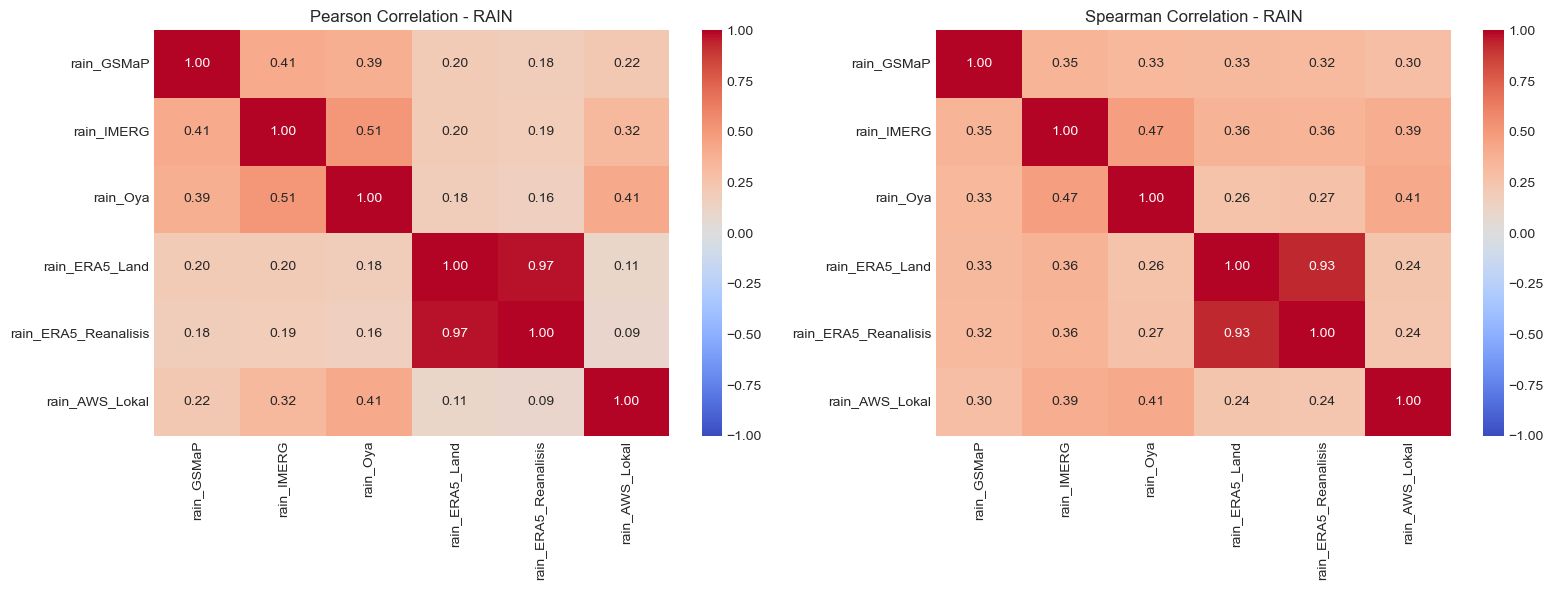

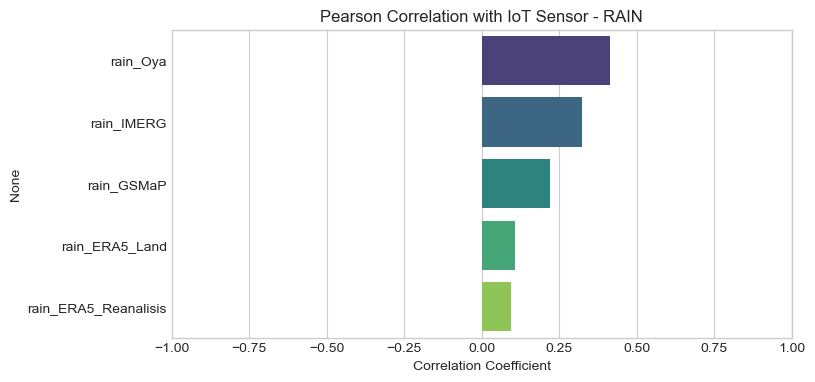

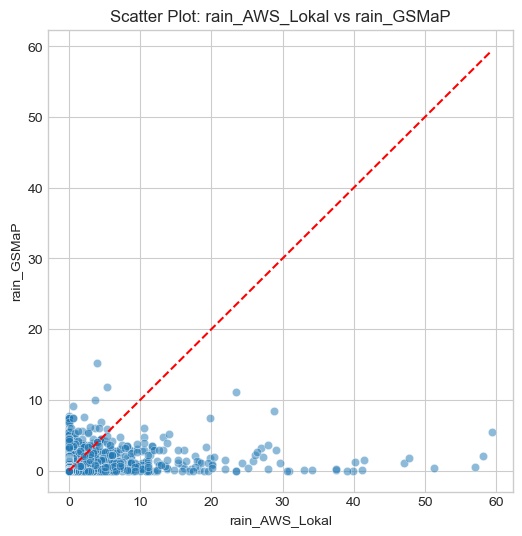

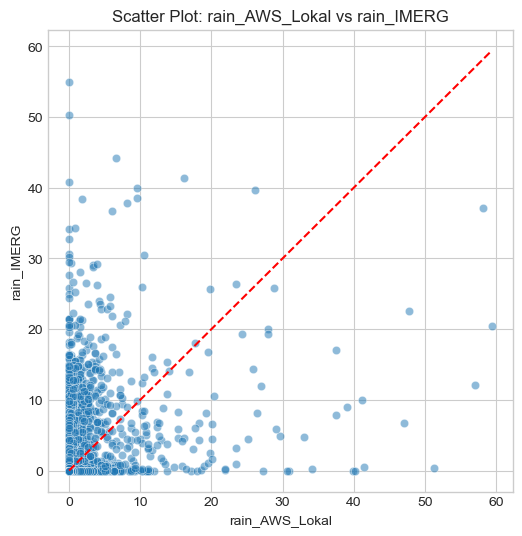

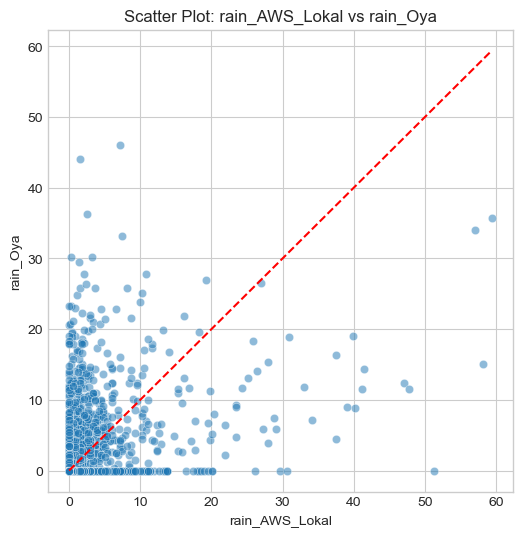

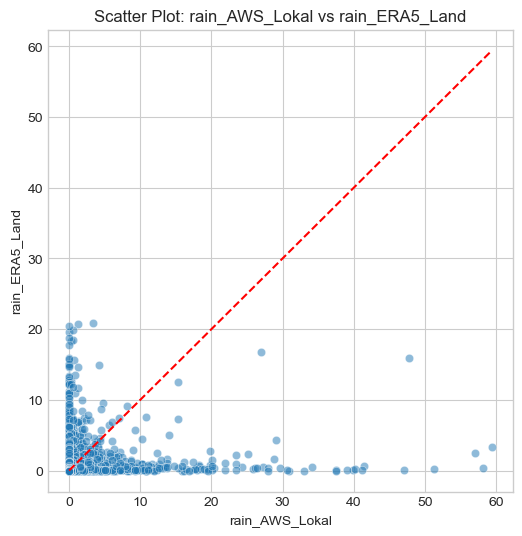

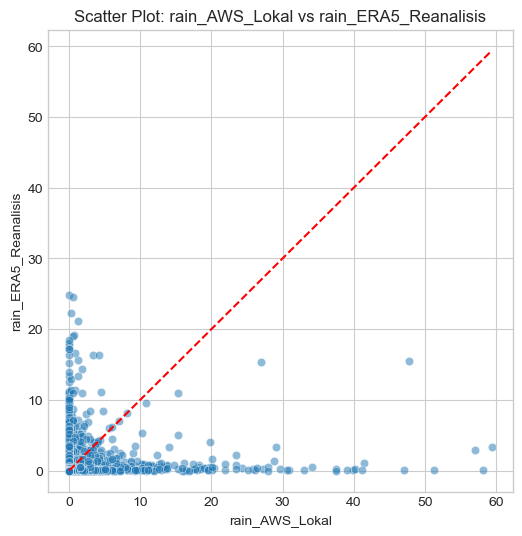

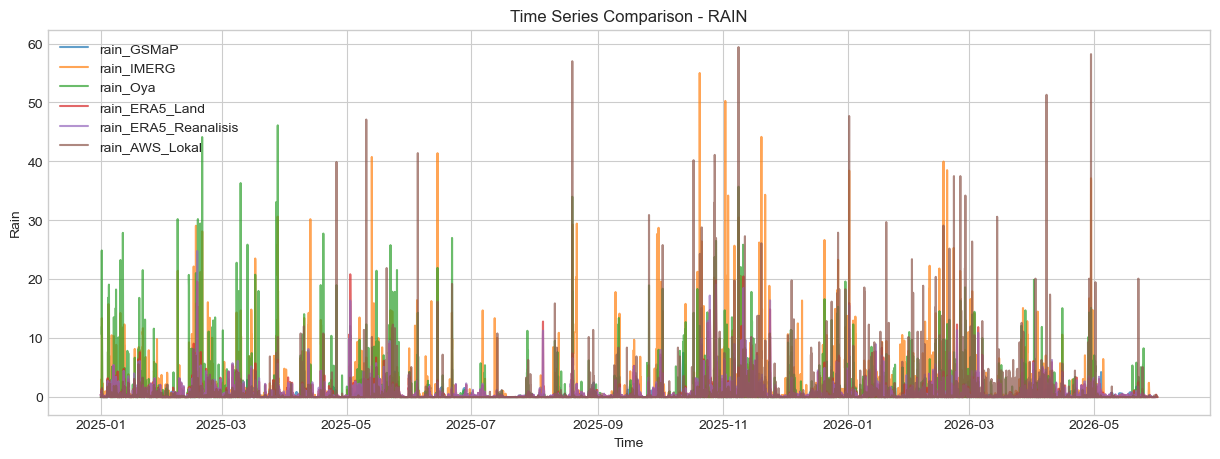

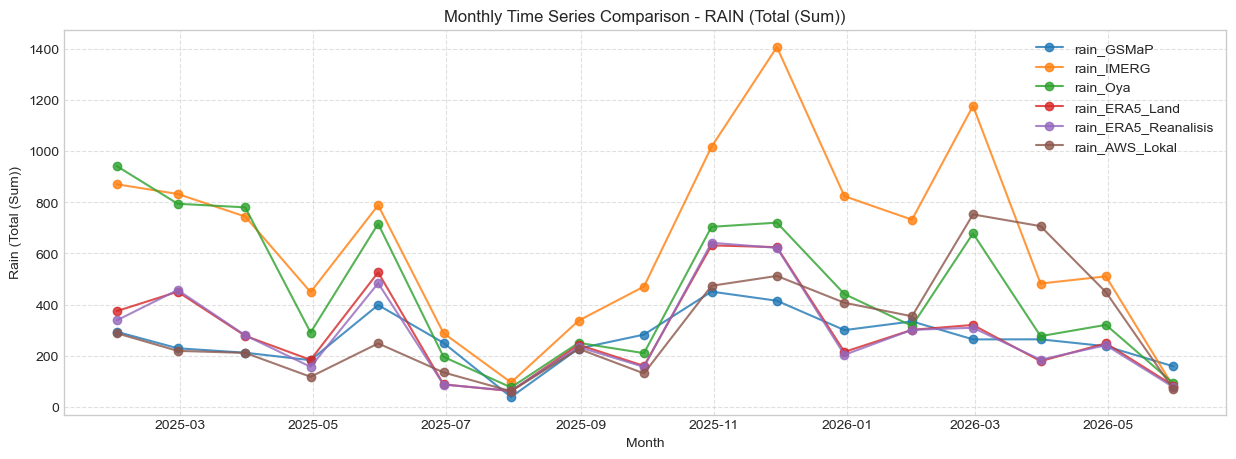

#### Hourly Time Series per Month (Rainfall only)

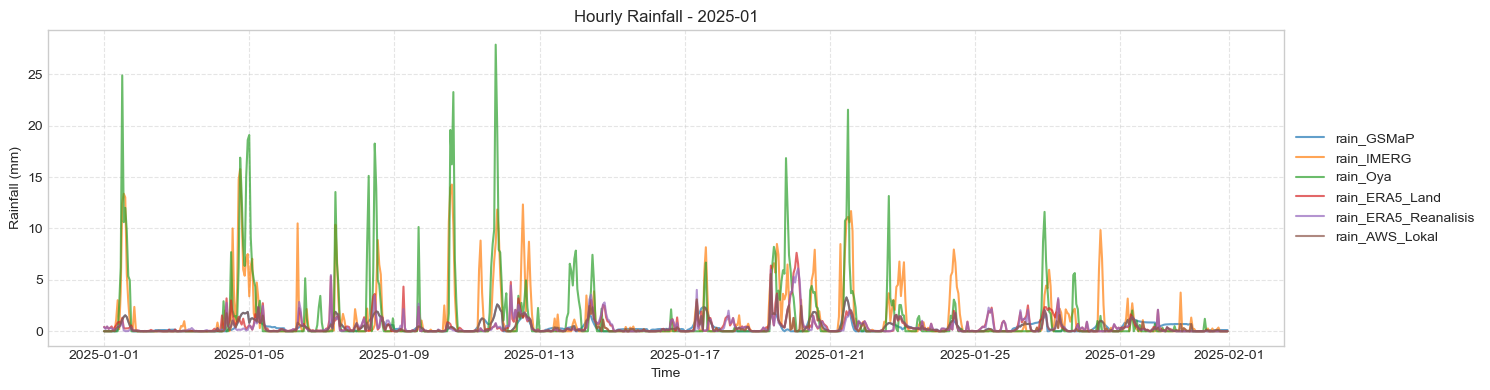

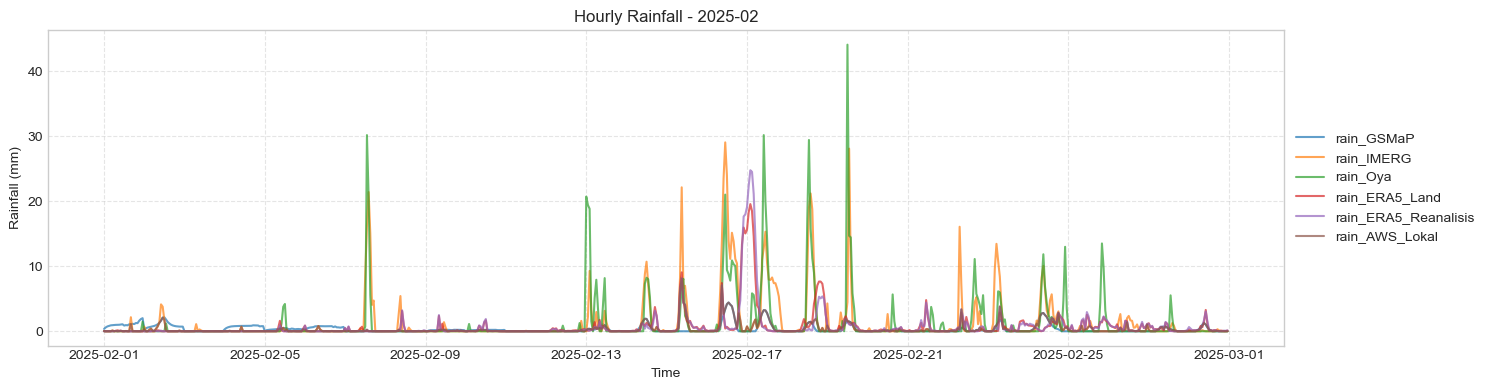

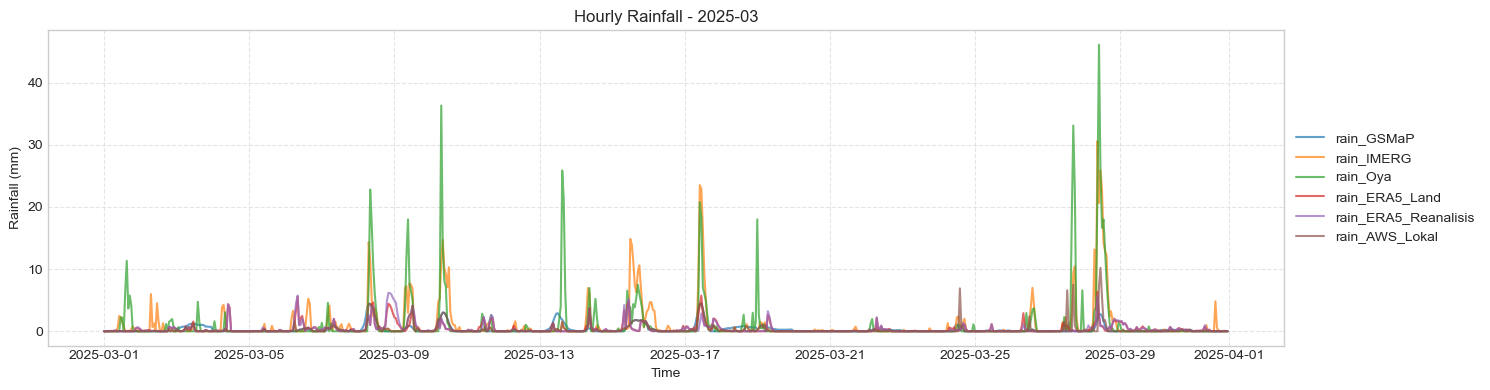

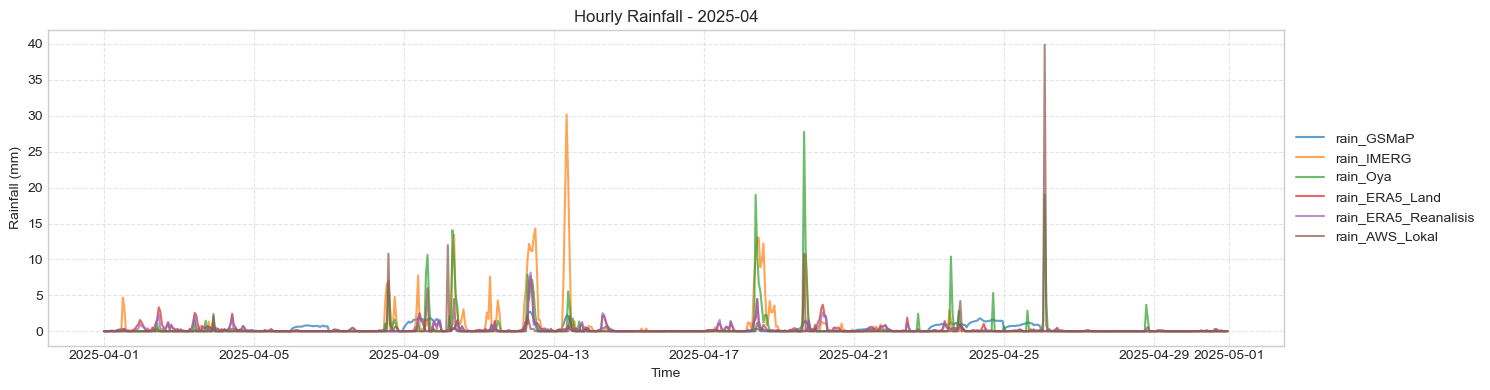

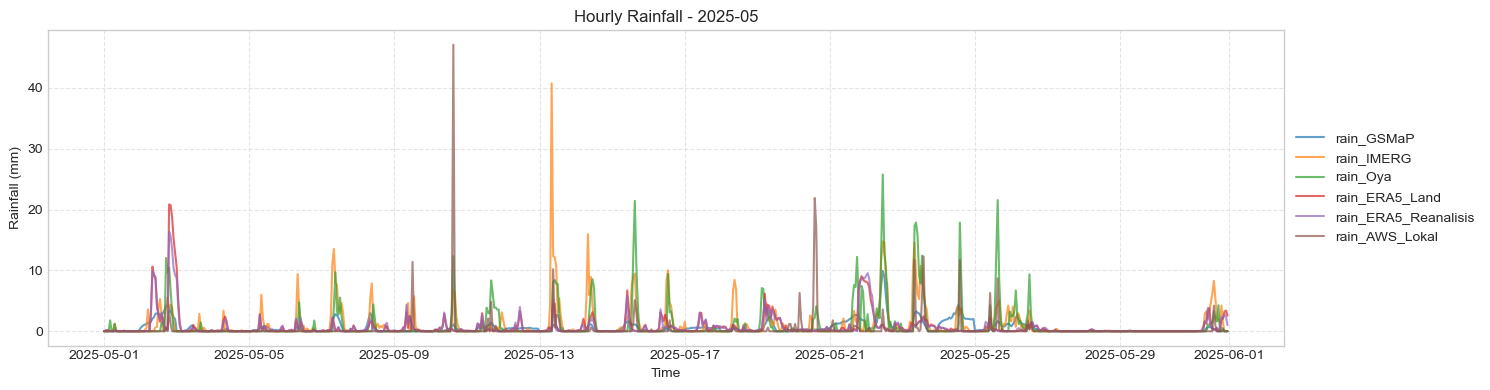

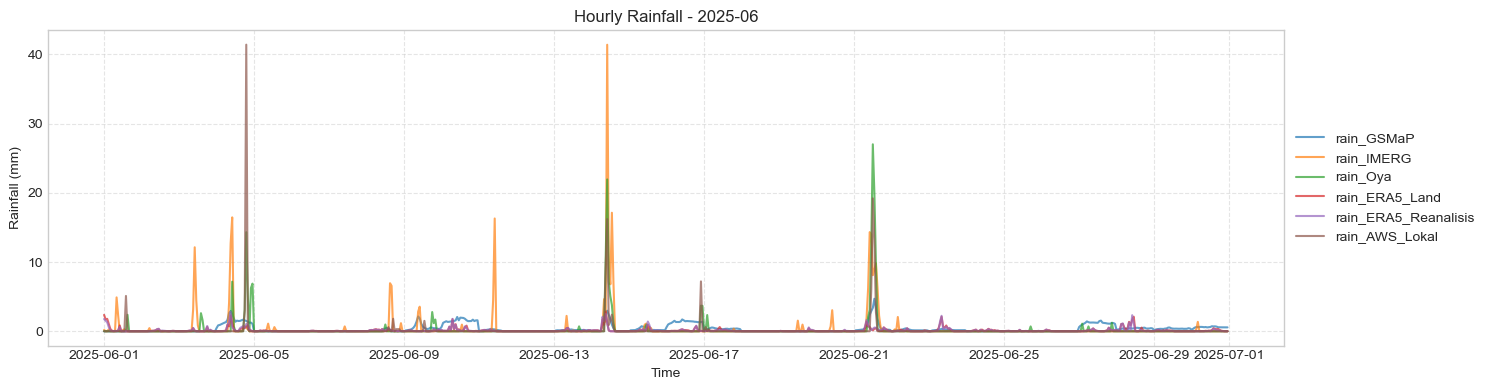

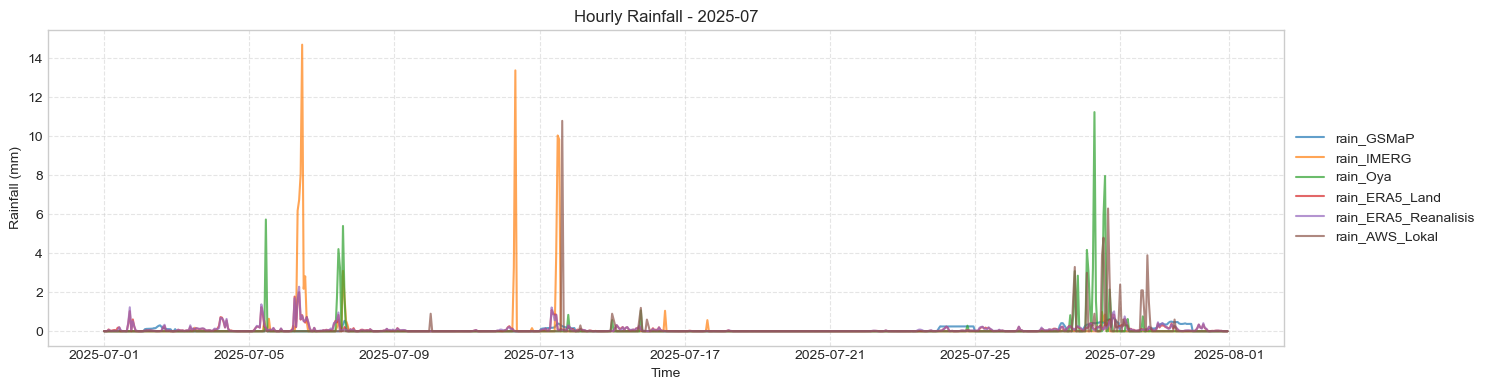

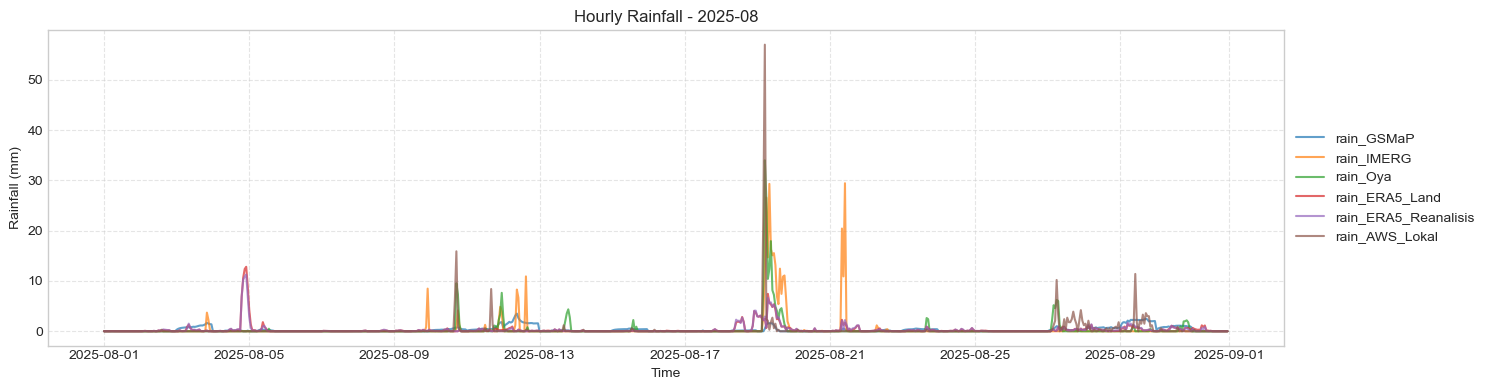

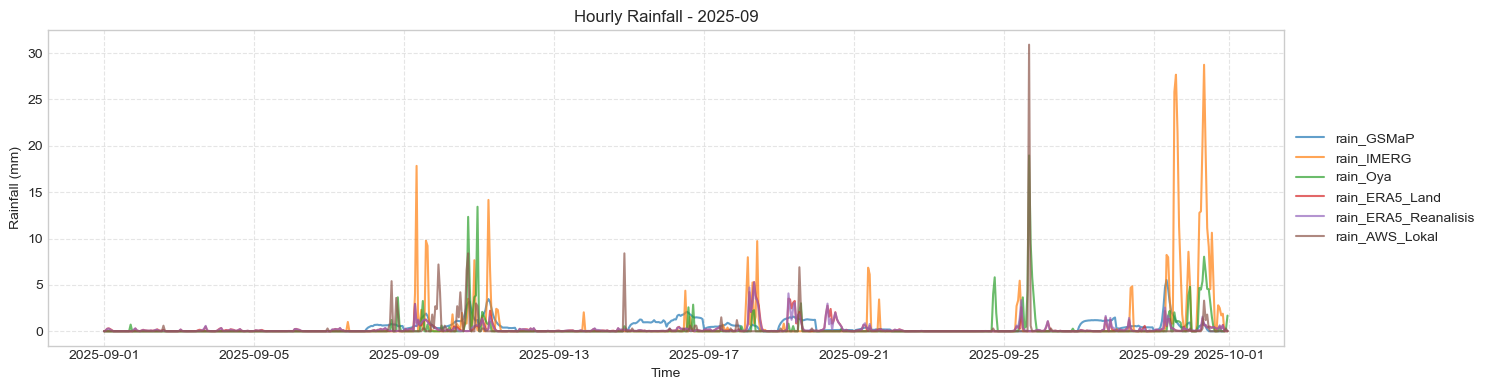

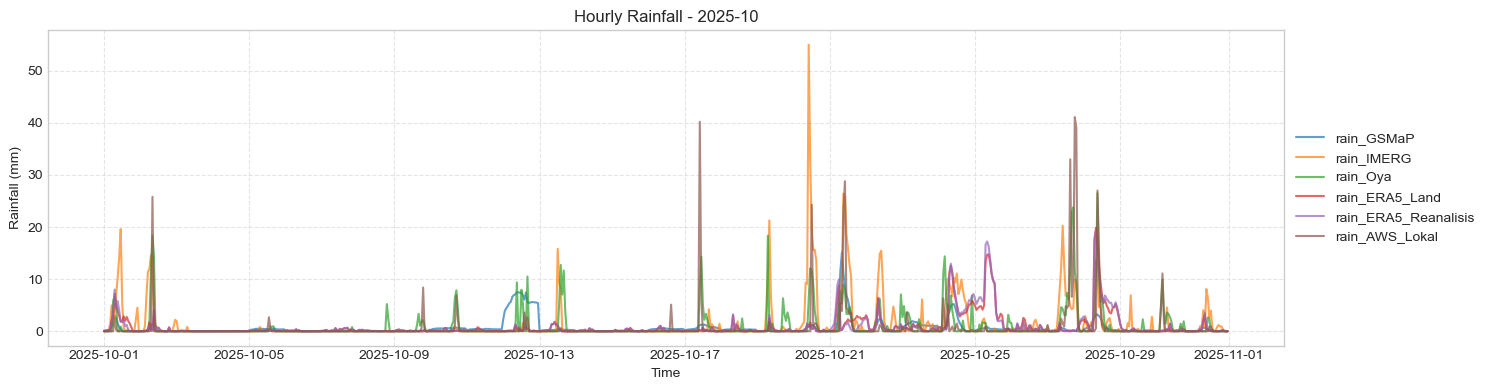

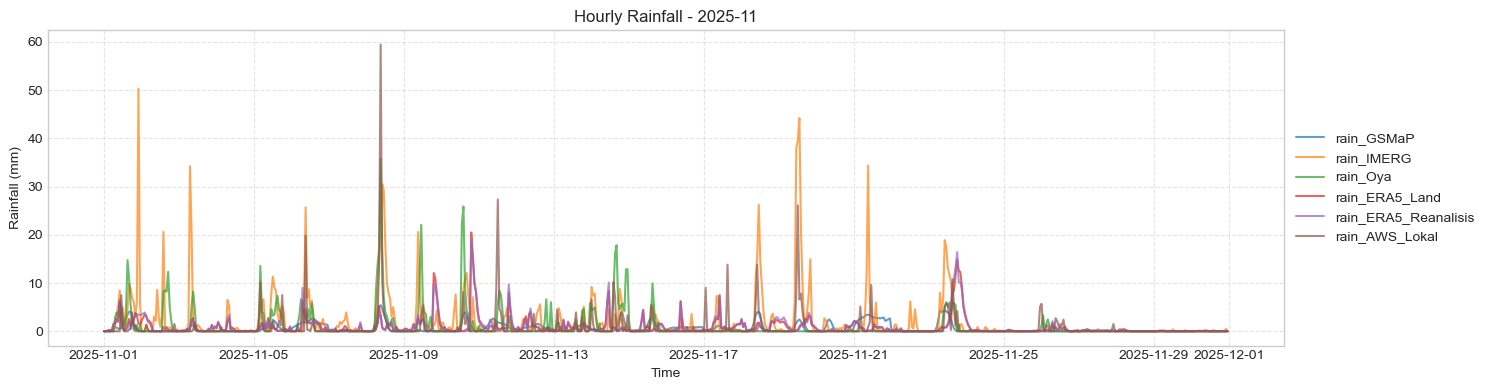

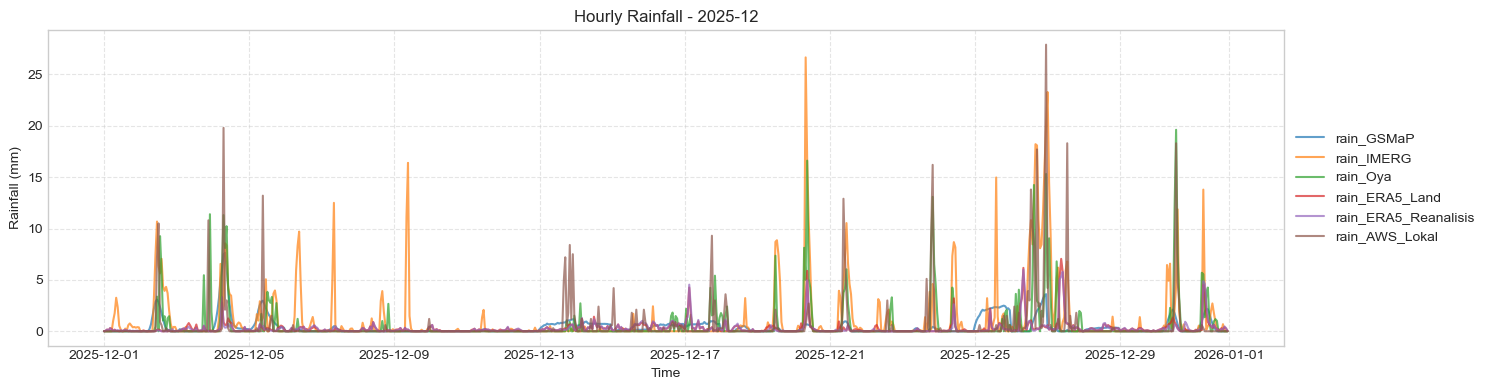

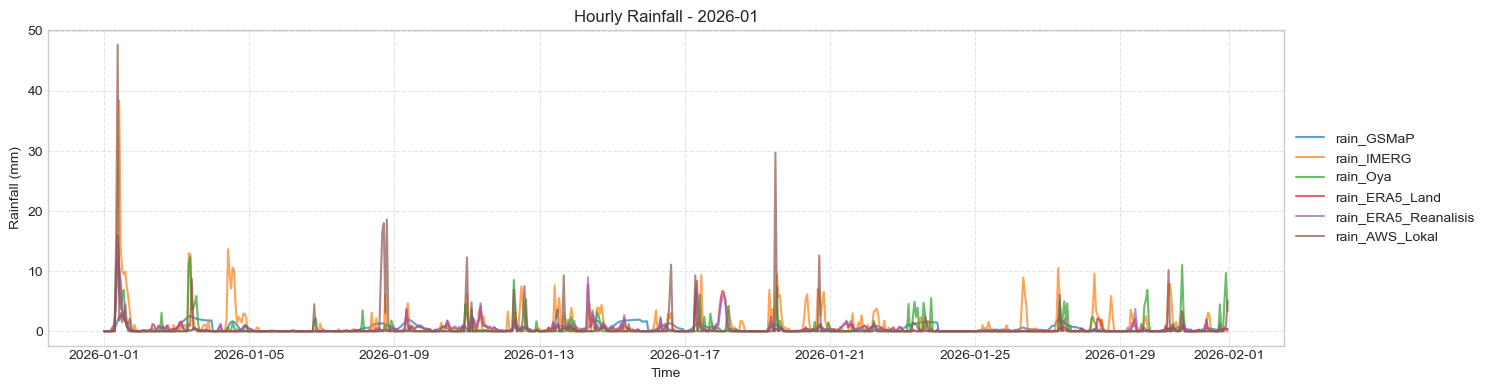

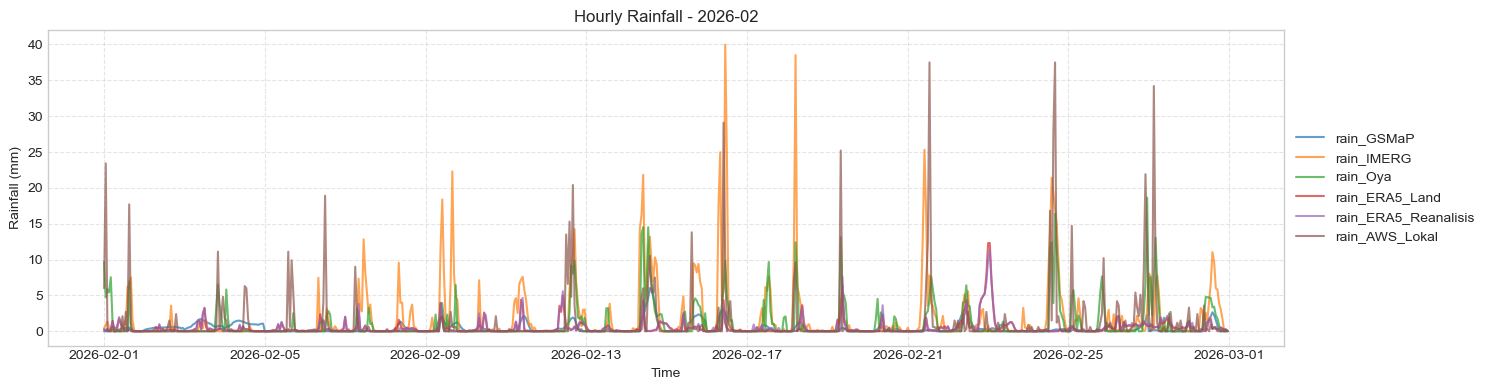

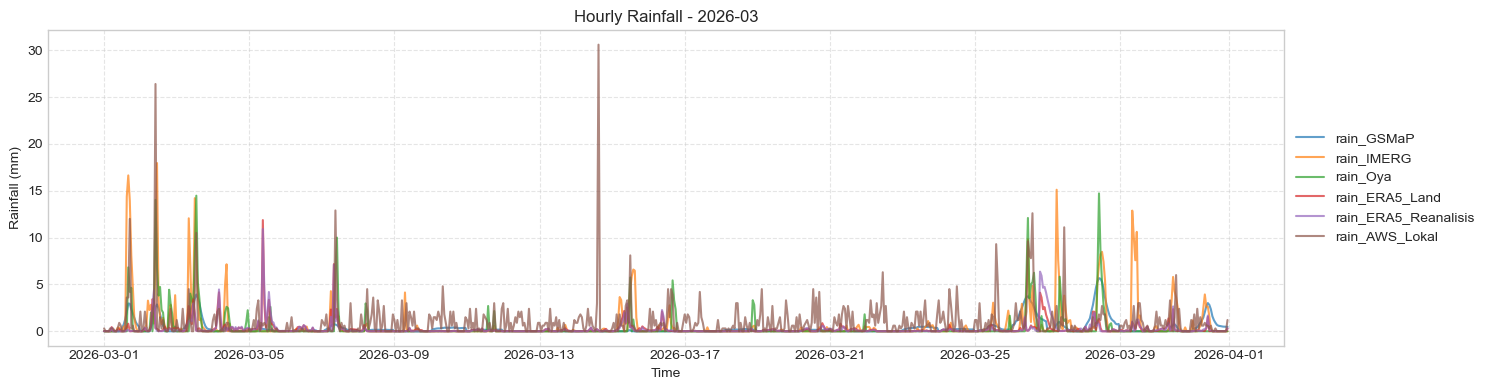

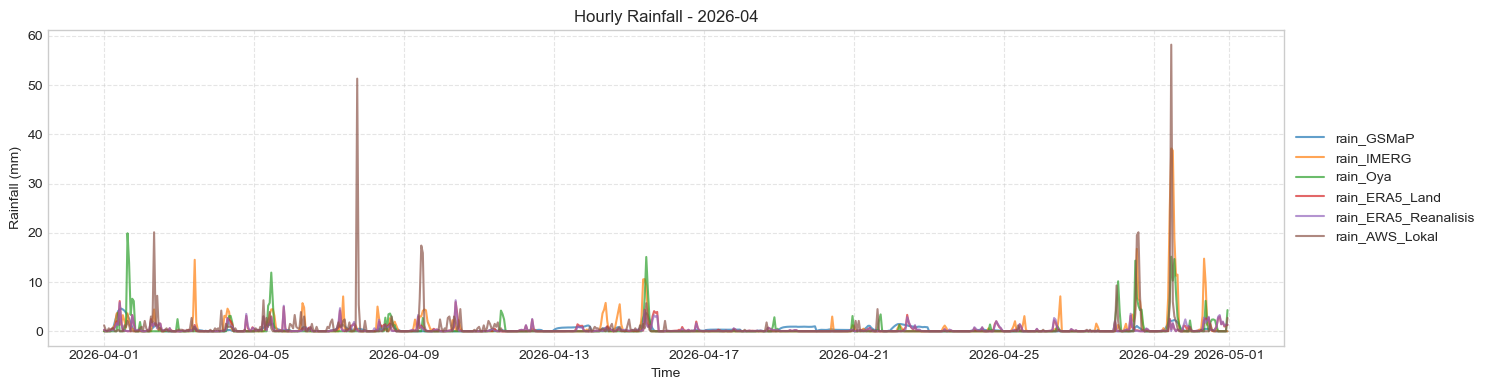

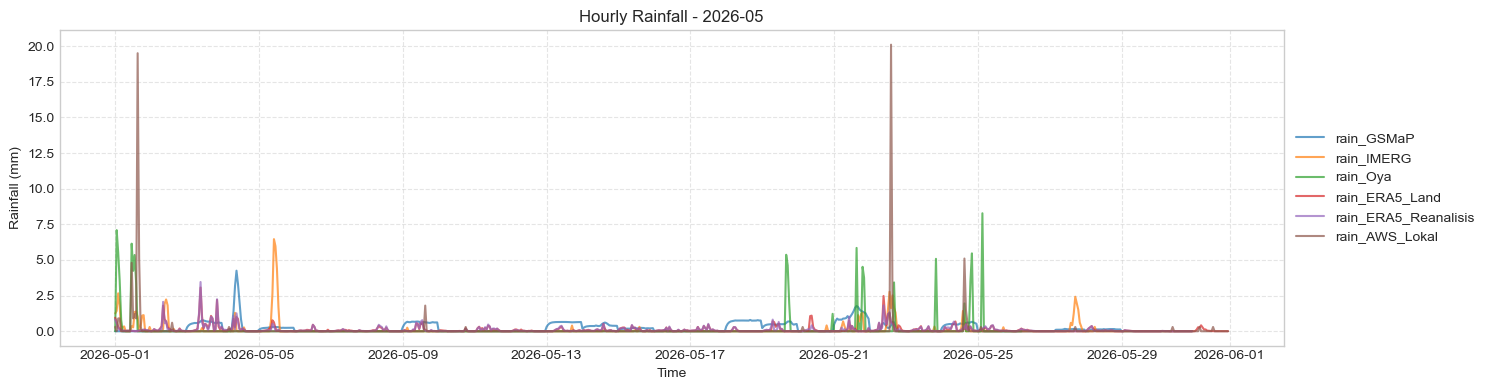

### Analysis for Variable: **PRESSURE**

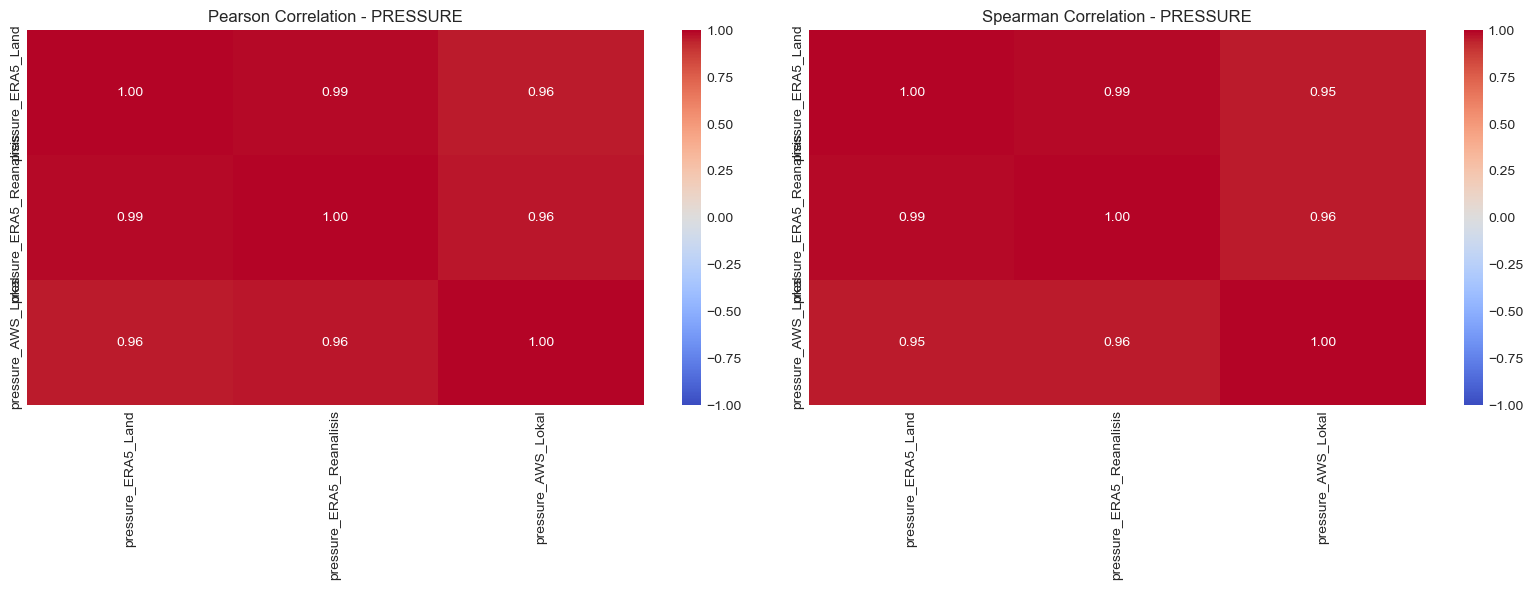

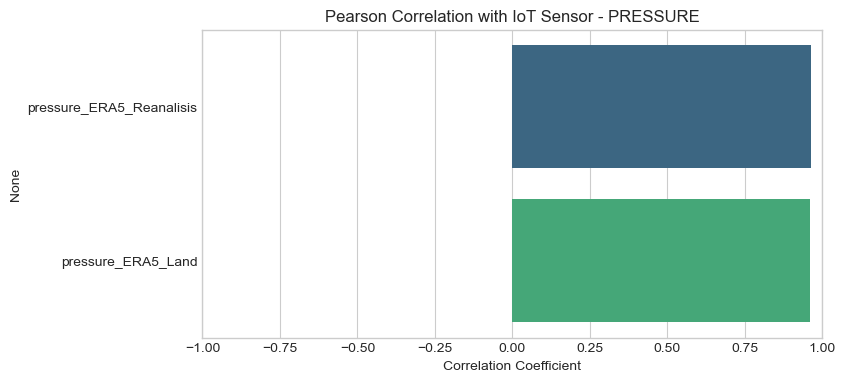

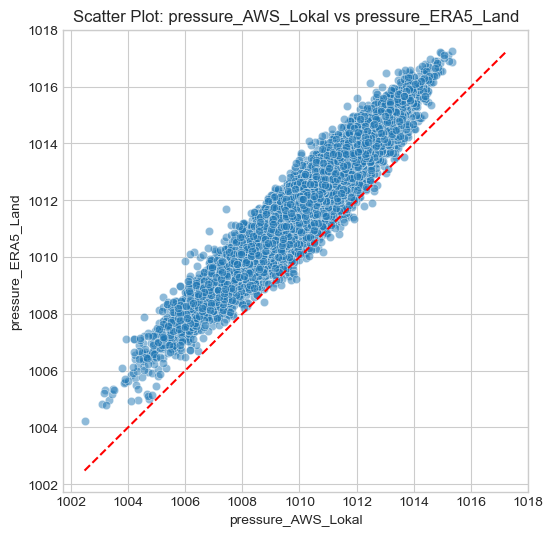

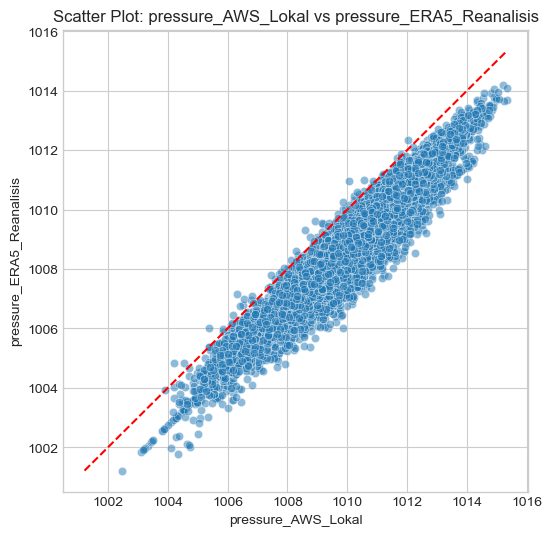

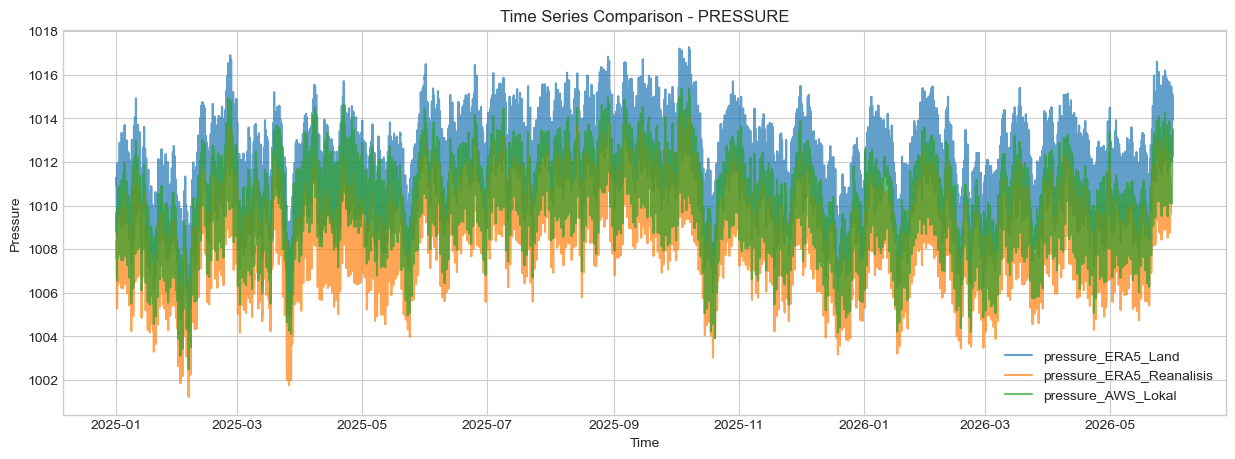

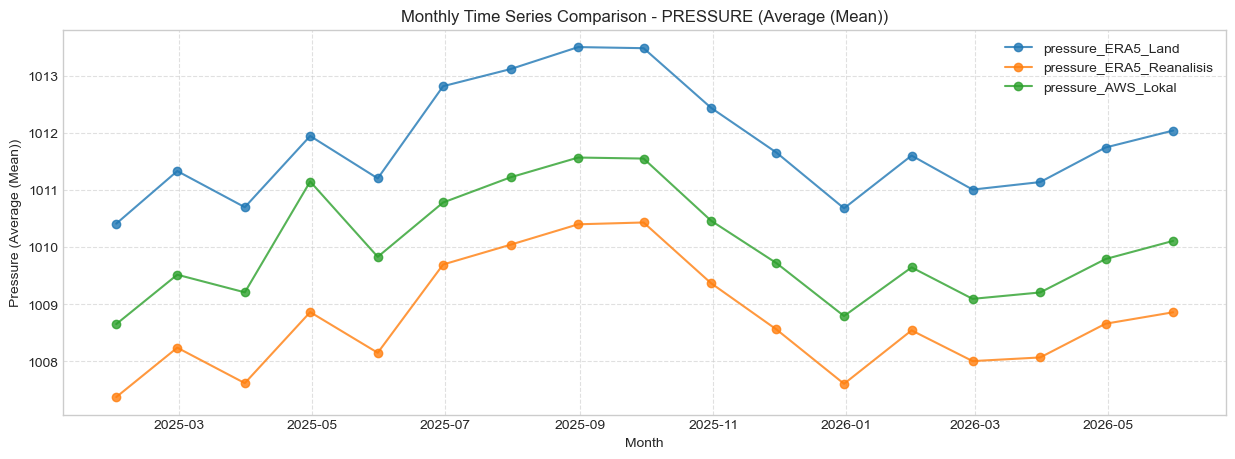

### Analysis for Variable: **DEWPOINT**

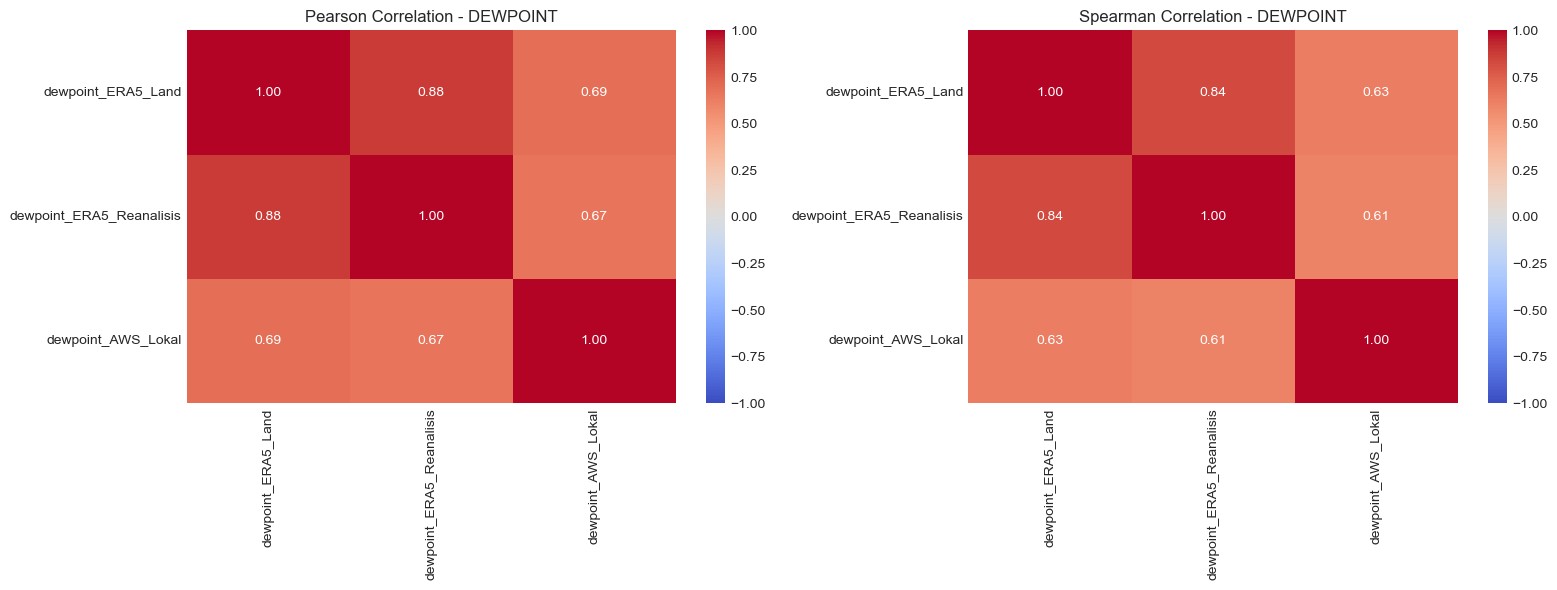

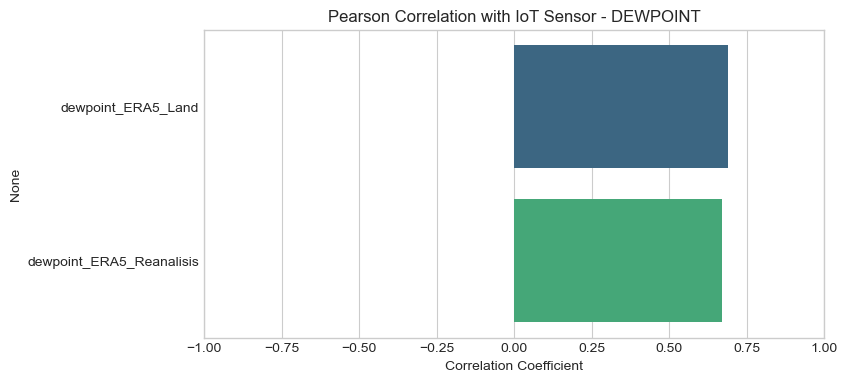

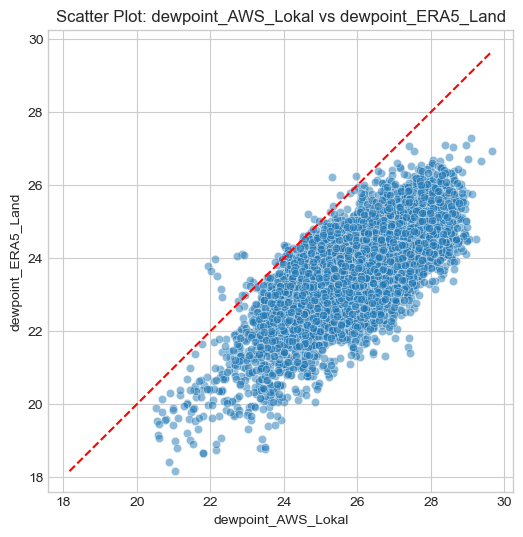

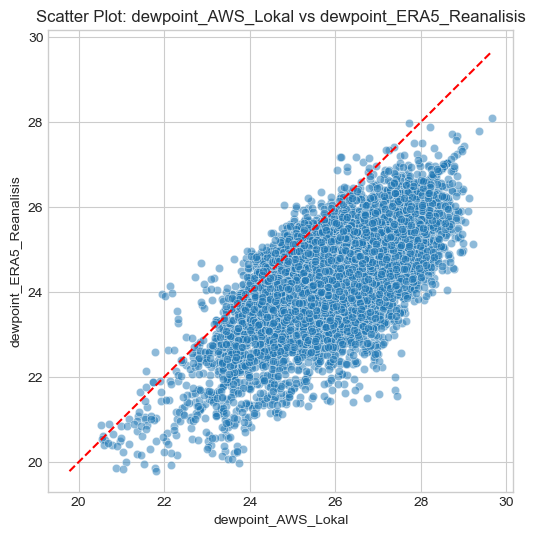

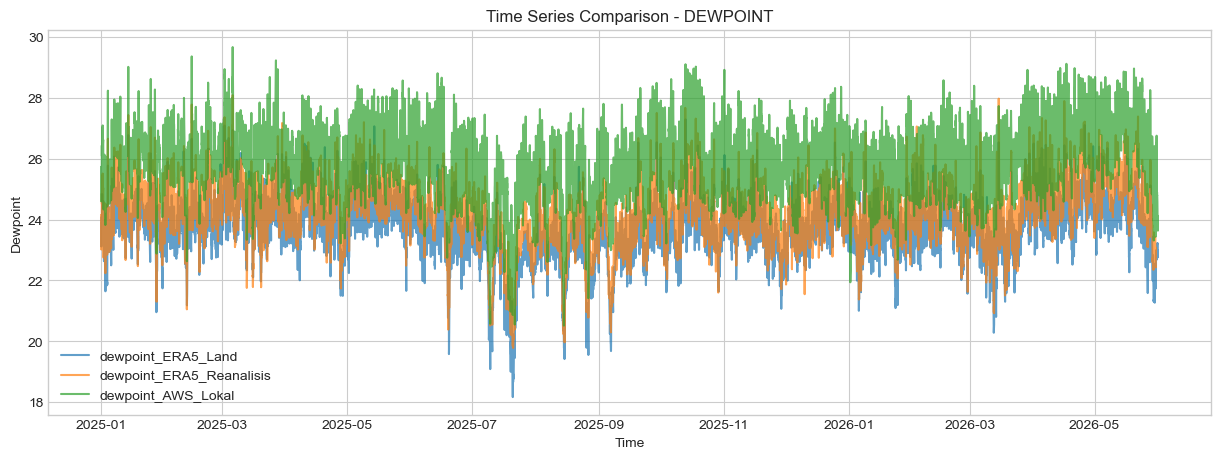

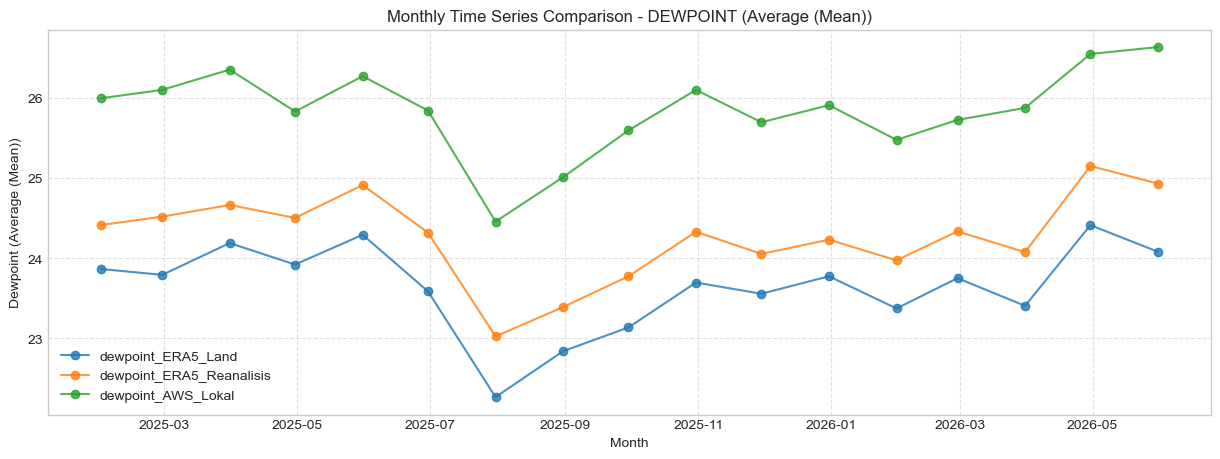

### Analysis for Variable: **HUMIDITY**

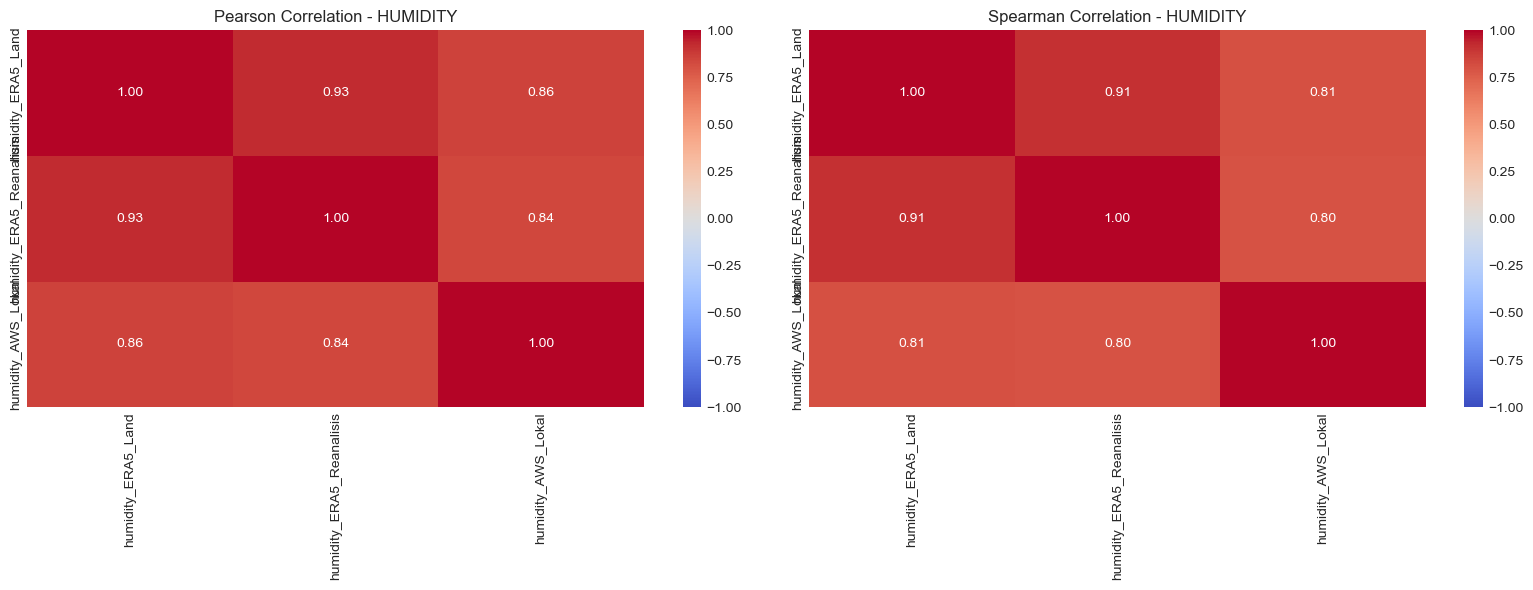

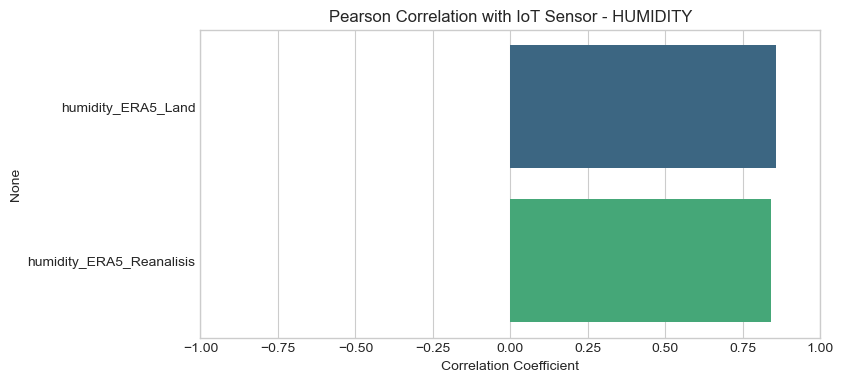

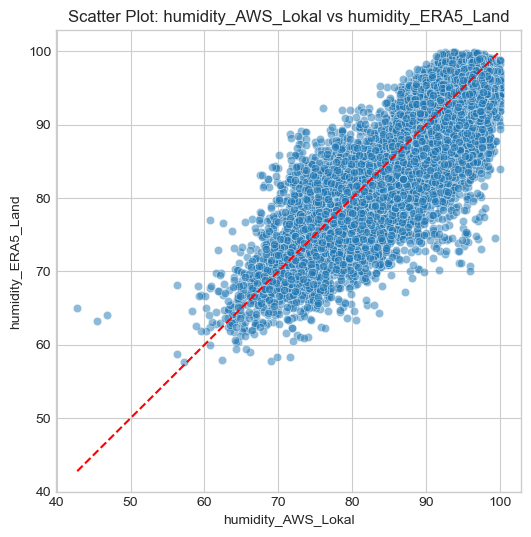

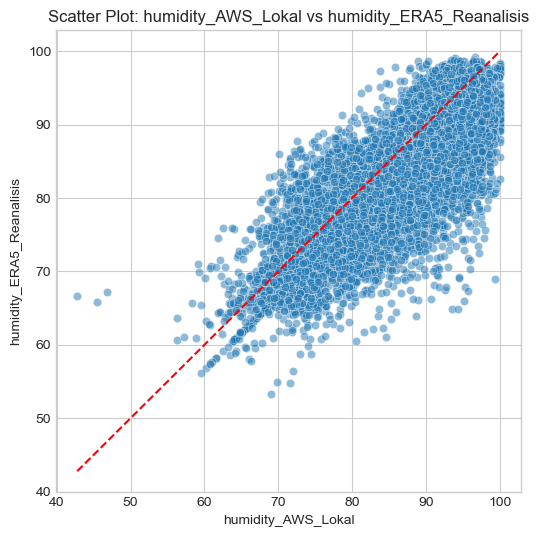

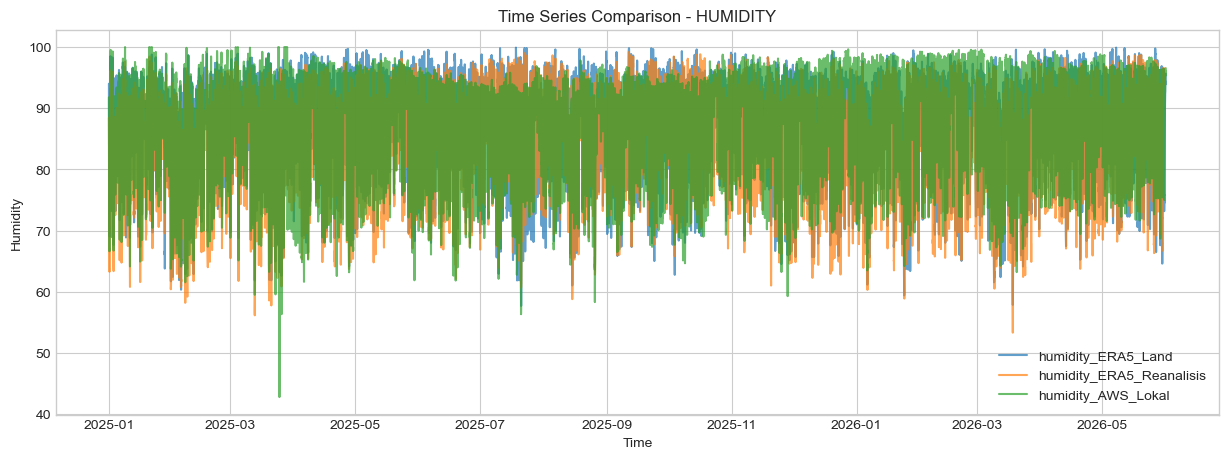

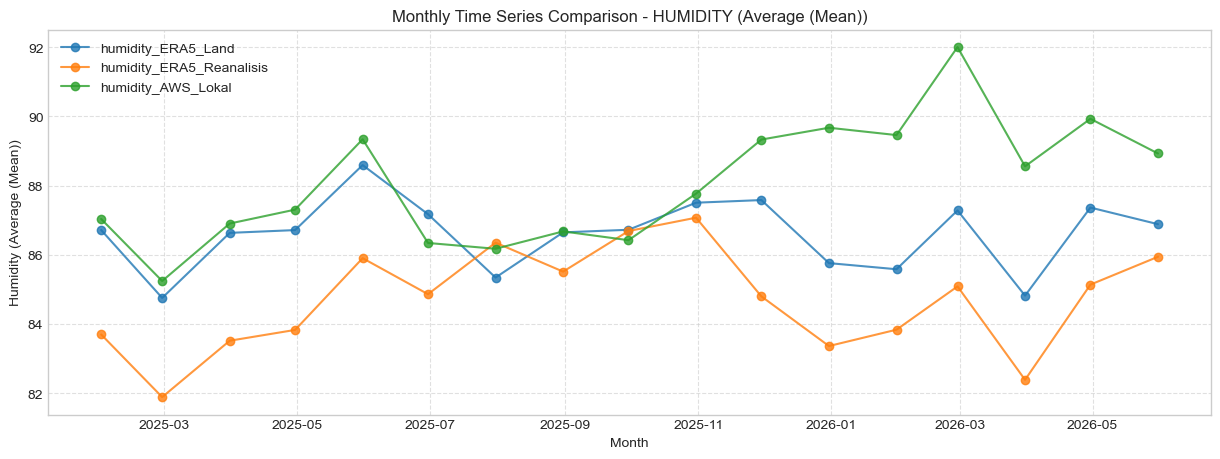

### Analysis for Variable: **TEMPERATURE**

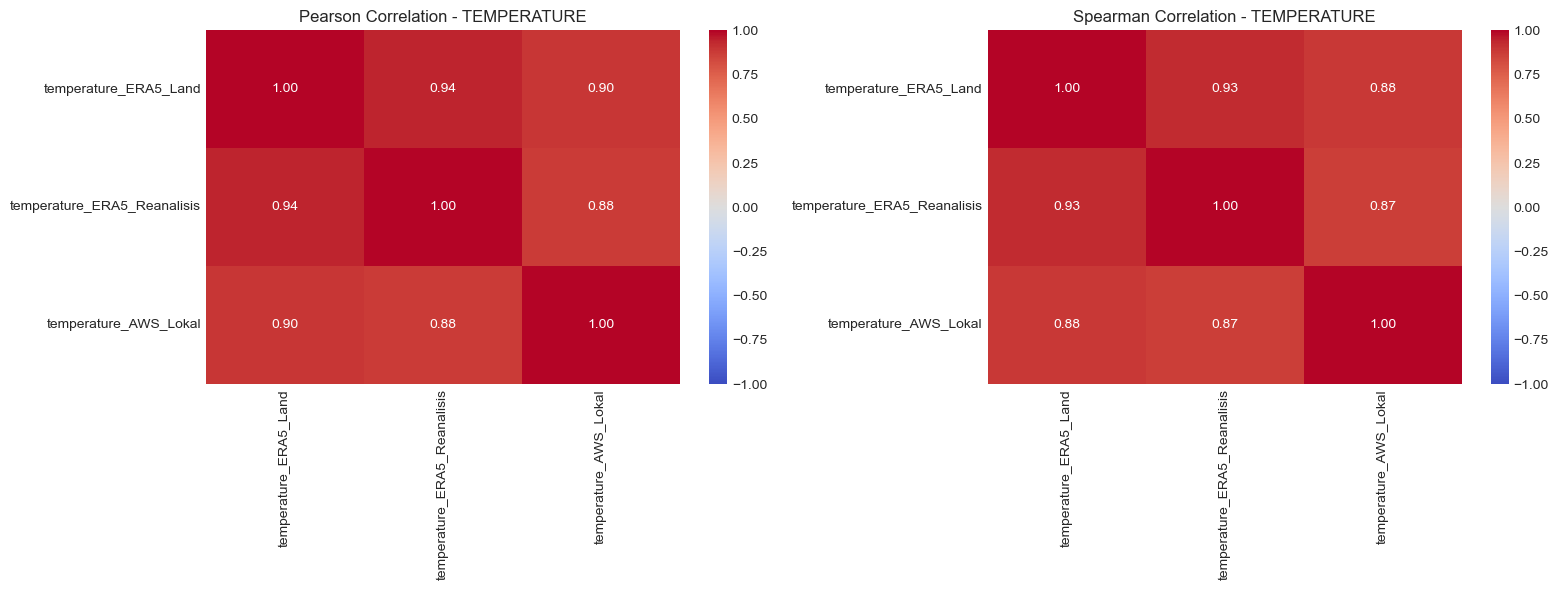

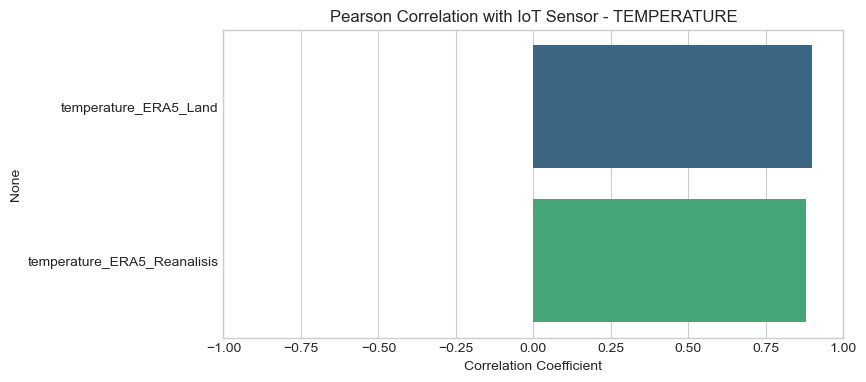

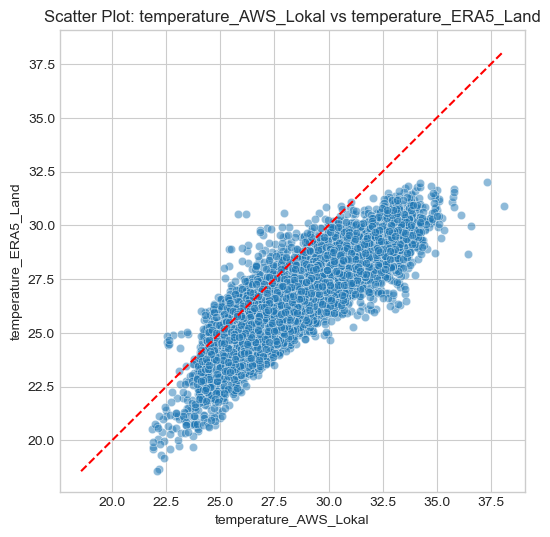

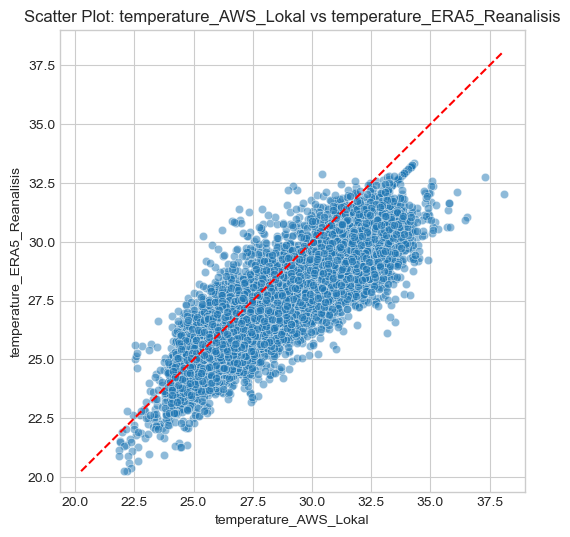

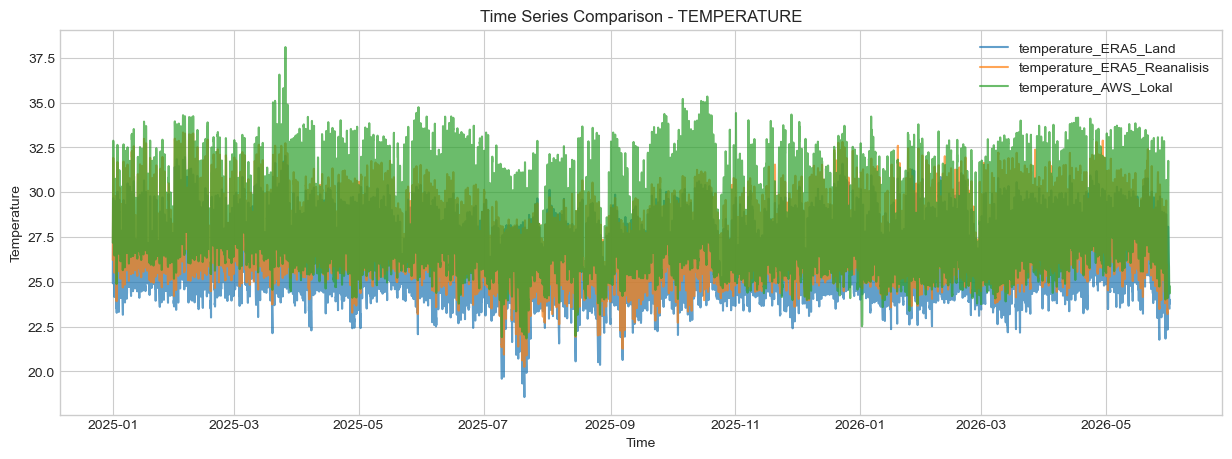

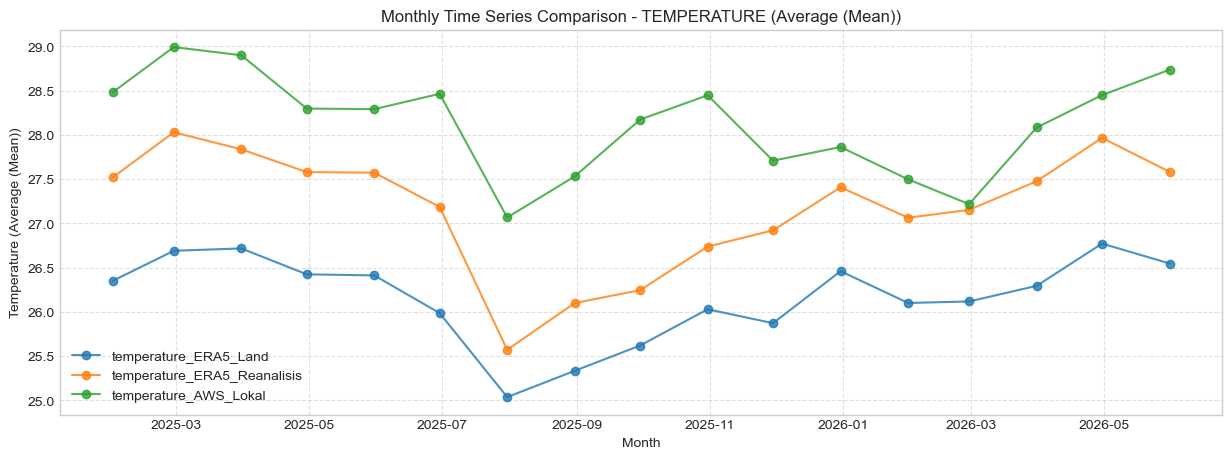

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

# Identify all variable types present in the merged dataframe
var_types = set([c.split('_')[0] for c in df_merged.columns])

for var in var_types:
    var_cols = [c for c in df_merged.columns if c.startswith(f'{var}_')]
    
    if len(var_cols) < 2:
        print(f"Skipping {var}: Not enough datasets to compare.")
        continue
        
    display(Markdown(f"### Analysis for Variable: **{var.upper()}**"))
    
    # 1. Calculate Correlations
    corr_pearson = df_merged[var_cols].corr(method='pearson')
    corr_spearman = df_merged[var_cols].corr(method='spearman')
    
    # 2. Plot Heatmaps
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.heatmap(corr_pearson, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", ax=axes[0])
    axes[0].set_title(f"Pearson Correlation - {var.upper()}")
    
    sns.heatmap(corr_spearman, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", ax=axes[1])
    axes[1].set_title(f"Spearman Correlation - {var.upper()}")
    plt.tight_layout()
    plt.show()
    
    # 3. Bar Chart vs IoT (if IoT exists for this variable)
    iot_col = None
    for cand in [f'{var}_AWS_Lokal', f'{var}_IoT_curah_hujan', f'{var}_AWS', f'{var}_IoT']:
        if cand in df_merged.columns:
            iot_col = cand
            break
    
    if iot_col and len(var_cols) > 1:
        corr_with_iot = corr_pearson[iot_col].drop(iot_col).sort_values(ascending=False)
        plt.figure(figsize=(8, 4))
        sns.barplot(x=corr_with_iot.values, y=corr_with_iot.index, palette='viridis')
        plt.title(f'Pearson Correlation with IoT Sensor - {var.upper()}')
        plt.xlabel('Correlation Coefficient')
        plt.xlim(-1, 1)
        plt.show()
    
    # 4. Scatter Plots against IoT
    if iot_col:
        compare_cols = [c for c in var_cols if c != iot_col]
        for col in compare_cols:
            plt.figure(figsize=(6, 6))
            sns.scatterplot(x=df_merged[iot_col], y=df_merged[col], alpha=0.5)
            
            # Perfect fit line
            min_val = min(df_merged[iot_col].min(), df_merged[col].min())
            max_val = max(df_merged[iot_col].max(), df_merged[col].max())
            plt.plot([min_val, max_val], [min_val, max_val], 'r--')
            
            plt.title(f'Scatter Plot: {iot_col} vs {col}')
            plt.xlabel(iot_col)
            plt.ylabel(col)
            plt.show()
            
    # 5. Time Series Comparison
    plt.figure(figsize=(15, 5))
    for col in var_cols:
        plt.plot(df_merged.index, df_merged[col], label=col, alpha=0.7)
    plt.title(f'Time Series Comparison - {var.upper()}')
    plt.xlabel('Time')
    plt.ylabel(var.capitalize())
    plt.legend()
    plt.show()

    # 6. Monthly Time Series Comparison
    plt.figure(figsize=(15, 5))
    if var == 'rain':
        df_monthly = df_merged[var_cols].resample('ME').sum()
        agg_label = 'Total (Sum)'
    else:
        df_monthly = df_merged[var_cols].resample('ME').mean()
        agg_label = 'Average (Mean)'
        
    for col in var_cols:
        plt.plot(df_monthly.index, df_monthly[col], marker='o', label=col, alpha=0.8)
    plt.title(f'Monthly Time Series Comparison - {var.upper()} ({agg_label})')
    plt.xlabel('Month')
    plt.ylabel(f"{var.capitalize()} ({agg_label})")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
    # 7. Rain: Monthly Subplots (Hourly resolution, split by month)
    if var == 'rain':
        display(Markdown("#### Hourly Time Series per Month (Rainfall only)"))
        # Group by Year-Month
        groups = df_merged[var_cols].groupby(df_merged.index.to_period('M'))
        
        for m, df_m in groups:
            if df_m.dropna(how='all').empty: continue
            
            plt.figure(figsize=(15, 4))
            for col in var_cols:
                valid_data = df_m[col].dropna()
                if not valid_data.empty:
                    plt.plot(valid_data.index, valid_data.values, label=col, alpha=0.7)
            
            plt.title(f'Hourly Rainfall - {m}')
            plt.xlabel('Time')
            plt.ylabel('Rainfall (mm)')
            # Put legend outside to avoid obscuring data
            plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
            plt.grid(True, linestyle='--', alpha=0.5)
            plt.tight_layout()
            plt.show()


In [52]:
audit_logs = []

missing = df_merged[[col for col in df_merged.columns if col.startswith('rain_')]].isna().sum()
negatives = (df_merged[[col for col in df_merged.columns if col.startswith('rain_')]] < 0).sum()
duplicates = df_merged.index.duplicated().sum()

audit_table = pd.DataFrame({
    'Missing Values': missing,
    'Negative Values': negatives
})

display(Markdown(f"- **Duplicated Timestamps in Aligned Data**: {duplicates}\n"))
display(audit_table)


- **Duplicated Timestamps in Aligned Data**: 0


,Missing Values,Negative Values
rain_GSMaP,24,0
rain_IMERG,24,0
rain_Oya,138,0
rain_ERA5_Land,0,74
rain_ERA5_Reanalisis,24,0
rain_AWS_Lokal,0,0


## Phase 10 — Recommendations

### Recommendations for Comparison with Local Weather Station

#### 1. Data Satelit (GSMaP, IMERG, Oya)
- **Suitability**: Sangat cocok untuk analisis klimatologi dan pemantauan area yang luas (spasial).
- **Extreme Rainfall**: Cenderung mengalami bias (underestimation) pada hujan konvektif yang sangat ekstrem. Dianjurkan menggunakan GSMaP_GC (Gauge Calibrated) sebagai acuan terbaik.

#### 2. Reanalisis ERA5 (Land & ML)
- **Kekuatan**: Konsistensi temporal sangat tinggi tanpa ada data bolong. Variabel hidrodinamik lengkap.
- **Batasan**: Bukan merupakan observasi langsung. Hujan skala mikro/lokal (<9km) tidak terekam dengan akurat.
- **Keterwakilan Temporal**: Baik digunakan sebagai baseline model prediktif (Machine Learning).

#### 3. Stasiun IoT Lokal (id-05)
- **Saran**: Jika digunakan sebagai *Reference Truth*, bias pada sensor (tipping bucket / optik) akibat *wind-induced undercatch* perlu dikalibrasi lebih lanjut. Strategi agregasi `SUM` per jam telah sesuai, tetapi pembersihan lonjakan nilai ekstrem harus selalu dipantau.


## Phase 11 — Export Results
Menyimpan data gabungan ke dalam folder output.

In [53]:
out_dir = os.path.join(base_dir, 'Hasil_Analisis')
os.makedirs(out_dir, exist_ok=True)

parquet_path = os.path.join(out_dir, 'unified_precipitation_comparison.csv')
csv_corr_path = os.path.join(out_dir, 'correlation_matrix.csv')

df_merged.to_csv(parquet_path)
corr_pearson.to_csv(csv_corr_path)

display(Markdown(f"✅ **EKSPORE SELESAI**\n- Dataset tersimpan di: `{parquet_path}`\n- Matrix korelasi tersimpan di: `{csv_corr_path}`"))


✅ **EKSPORE SELESAI**
- Dataset tersimpan di: `d:/Github/Projek_Rainfall/Google_Earth_Engine\Hasil_Analisis\unified_precipitation_comparison.csv`
- Matrix korelasi tersimpan di: `d:/Github/Projek_Rainfall/Google_Earth_Engine\Hasil_Analisis\correlation_matrix.csv`

In [54]:
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

# Hitung Metrik Bias (MBE, MAE, RMSE) antara Observasi (IoT) dan Data Satelit/Model
bias_metrics = []
for var in var_types:
    if var == 'rain':
        continue # Hanya untuk variabel linear (Suhu, Kelembapan, Tekanan, Titik Embun)
        
    var_cols = [c for c in df_merged.columns if c.startswith(f'{var}_')]
    iot_col = None
    for cand in [f'{var}_AWS_Lokal', f'{var}_IoT_curah_hujan', f'{var}_AWS', f'{var}_IoT']:
        if cand in df_merged.columns:
            iot_col = cand
            break
    
    if iot_col:
        for col in var_cols:
            if col != iot_col:
                # Valid data masking
                mask = df_merged[iot_col].notna() & df_merged[col].notna()
                obs = df_merged.loc[mask, iot_col]
                pred = df_merged.loc[mask, col]
                
                if len(obs) > 0:
                    mbe = np.mean(pred - obs)  # Mean Bias Error
                    mae = np.mean(np.abs(pred - obs)) # Mean Absolute Error
                    rmse = np.sqrt(np.mean((pred - obs)**2)) # RMSE
                    
                    bias_metrics.append({
                        'Variable': var.capitalize(),
                        'Model/Dataset': col.replace(f'{var}_', ''),
                        'MBE (Bias)': mbe,
                        'MAE': mae,
                        'RMSE': rmse
                    })

if bias_metrics:
    df_bias = pd.DataFrame(bias_metrics)
    display(Markdown("### Analisis Bias Error (Model vs Observasi IoT)"))
    display(Markdown("**MBE (Mean Bias Error)** menunjukkan seberapa meleset data satelit/model secara rata-rata (positif = overestimate, negatif = underestimate)."))
    display(df_bias.round(3))

    df_bias.to_csv(os.path.join(out_dir, 'bias_error_metrics.csv'), index=False)



### Analisis Bias Error (Model vs Observasi IoT)

**MBE (Mean Bias Error)** menunjukkan seberapa meleset data satelit/model secara rata-rata (positif = overestimate, negatif = underestimate).

,Variable,Model/Dataset,MBE (Bias),MAE,RMSE
0,Pressure,ERA5_Land,1.797,1.799,1.885
1,Pressure,ERA5_Reanalisis,-1.282,1.284,1.386
2,Dewpoint,ERA5_Land,-2.206,2.209,2.369
3,Dewpoint,ERA5_Reanalisis,-1.582,1.603,1.819
4,Humidity,ERA5_Land,-1.465,3.713,4.928
5,Humidity,ERA5_Reanalisis,-3.353,4.678,5.910
6,Temperature,ERA5_Land,-1.969,2.026,2.284
7,Temperature,ERA5_Reanalisis,-0.963,1.237,1.574
